In [182]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

In [79]:
cpal = sns.color_palette('colorblind')

In [19]:
x = range(1990, 2041, 1)

In [211]:
df = pd.read_csv('results.csv').iloc[2:].reset_index(drop=True)

In [214]:
df = df.iloc[1:]
df.drop(index=5, inplace=True)

In [216]:
dict_responses = {
    q: pd.DataFrame(np.array( df[f'drawit_q{q}_finalY'].apply(lambda x: x.split(',')).tolist(), dtype=float ).T, index=x)
    for q in range(6)
}

In [217]:
dict_empirical = {
    0: pd.Series(
        [51.141, 51.228, 51.221, 51.235, 51.219, 51.208, 51.207, 51.197, 51.173, 51.179, 51.187, 51.199, 51.226, 51.212, 51.219, 51.234, 51.231, 51.199, 51.181, 51.121, 51.106, 51.192, 51.203, 51.196, 51.19, 51.161, 51.162, 51.18, 51.165, 51.192, 51.212, 51.141, 51.175, 51.266, 51.248, 51.182, 51.152, 51.176, 51.199, 51.203, 51.215, 51.246, 51.284, 51.305, 51.299, 51.297, 51.333, 51.336, 51.33, 51.331, 51.323, 51.307, 51.312, 51.355, 51.356, 51.328, 51.314, 51.319, 51.314, 51.315, 51.3, 51.302, 51.36, 51.373, 51.35, 51.369, 51.367, 51.335, 51.337, 51.337, 51.329, 51.333, 51.342, 51.361],
        index=[1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023], name='empirical'
    ),
    1: pd.Series(
        [0.0, 0.0, 0.0, 0.001, 0.026, 0.046, 0.071, 0.139, 0.273, 0.528, 0.66, 1.538, 1.686, 1.976, 2.388, 2.806, 3.95, 4.38, 5.12, 7.5, 10.07, 11.1, 12.3, 13.5, 14.9, 16.5, 18.2, 20.081, 29.524, 43.405, 55.9, 70.0],
        index=[1990, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2022, 2025], name='empirical'
    ),
    2: pd.Series(
        [76, 72, 69, 69, 67, 72, 74, 74, 75, 78, 74, 75, 73, 74, 73, 73],
        index=[2002, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], name='empirical'
    ),
    3: pd.Series(
        [31, 33, 29, 35, 39, 37, 39, 41, 46, 46, 44, 43, 48, 45, 46, 45],
        index=[2008, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], name='empirical'
    ),
    4: pd.Series(
        [60, 61, 59, 66, 64, 65, 66, 71, 73, 73, 70, 72, 72, 70, 70, 72],
        index=[2008, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], name='empirical'
    ),
    5: pd.Series(
        [23, 13, 16, 12, 3],
        index=[1981, 1989, 2005, 2010, 2017], name='empirical'
    )
}

In [218]:
def get_quality(q):
    temp = dict_responses[q].merge(
        dict_empirical[q],
        left_index=True, right_index=True, how='inner'
    )
    
    return [np.abs(temp[i] - temp['empirical']).mean() for i in temp.columns if i!='empirical']

In [201]:
def plot_summary(q):
    temp = pd.DataFrame(np.array( df[f'drawit_q{q}_finalY'].apply(lambda x: x.split(',')).tolist(), dtype=float ).T, index=x)

    fig, ax = plt.subplots(1,1,figsize=(6,4))
    ax.plot(temp.index, temp, color=cpal[0], alpha=0.5, ls=':')
    ax.plot( temp.apply(np.median, axis=1), color=cpal[0], label='median')
    ax.fill_between(
        temp.index,
        temp.apply(lambda x:np.quantile(x, .4), axis=1), 
        temp.apply(lambda x:np.quantile(x, .6), axis=1), 
        alpha=0.3, label='+- 10 percentile', color=cpal[0]
    )
    ax.fill_between(
        temp.index, 
        temp.apply(lambda x:np.quantile(x, .3), axis=1), 
        temp.apply(lambda x:np.quantile(x, .7), axis=1), 
        alpha=0.1, label='+- 20 percentile', color=cpal[0]
    )
    
    
    ax.plot(
        dict_empirical[q], c='black', label='empirical', marker='o'
    )
    
    plt.legend()
    ax.set_xlabel('year')
    ax.set_ylabel('percentage of population')
    ax.set_xlim(min(x), max(x))
    ax.set_ylim(0, 100)
    


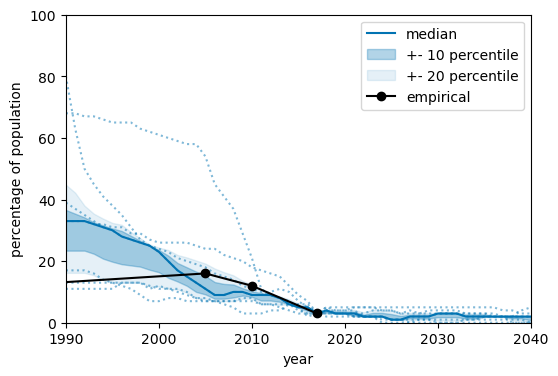

In [232]:
plot_summary(5)